# AI-Based IT Helpdesk Ticket Analysis & Resolution Prediction

## Problem Statement

IT organizations handle a large volume of helpdesk tickets related to technical issues and support requests. However, analyzing these tickets manually makes it difficult to identify recurring problems, understand resolution patterns, and estimate how long a new ticket may take to resolve.

This Sprint 1 project focuses on understanding and analyzing IT helpdesk ticket data, including ticket priority, issue type, project distribution, comments, contributors, and resolution time. The dataset will be cleaned, analyzed, and visualized using Python, NumPy, Pandas, and Matplotlib.


## Objectives

- Understand the IT helpdesk ticket dataset.
- Inspect and clean the relevant data.
- Analyze ticket priority, issue type, and project distribution.
- Calculate ticket resolution time.
- Perform basic statistical analysis using NumPy.
- Analyze patterns related to resolution time using Pandas.
- Visualize important findings using Matplotlib.


## Technologies Used

- Python
- NumPy
- Pandas
- Matplotlib
- Jupyter Notebook


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

## 2. Load the Dataset

In [2]:
zip_path = "Help Desk Tickets.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print("Files available in ZIP:")
    print("\n".join(z.namelist()))

    df = pd.read_csv(z.open("Help Desk Tickets/issues.csv"))

print("\nDataset loaded successfully.")

Files available in ZIP:
Help Desk Tickets/issues_change_history.csv
Help Desk Tickets/issues.csv
Help Desk Tickets/issues_snapshot.csv
Help Desk Tickets/process-flow.png
Help Desk Tickets/EXAMPLE.md
Help Desk Tickets/issues_snapshot_sample.xlsx
Help Desk Tickets/sample_utterances.csv
Help Desk Tickets/db.png
Help Desk Tickets/holidays_by_country.csv
Help Desk Tickets/FEATURES.md



Dataset loaded successfully.


## 3. Dataset Overview

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 66691
Columns: 58


,id,started,ended,issue_num,issue_proj,issue_reporter,issue_assignee,issue_contr_count,issue_type,issue_priority,issue_created,issue_resolution_date,issue_resolution,issue_status,issue_comments_count,last_change_date,wf_in_review,wfe_in_review,wf_deployment,wfe_deployment,wf_resolved,wfe_resolved,wf_open,wfe_open,wf_monitoring,wfe_monitoring,wf_done,wfe_done,wf_pending_customer_approval,wfe_pending_customer_approval,wf_rejected,wfe_rejected,wf_testing_monitoring,wfe_testing_monitoring,wf_in_progress,wfe_in_progress,wf_reopened,wfe_reopened,wf_to_do,wfe_to_do,wf_validation,wfe_validation,wf_resolved_under_monitoring,wfe_resolved_under_monitoring,wf_closed,wfe_closed,wf_waiting,wfe_waiting,wf_cancelled,wfe_cancelled,wf_under_review,wfe_under_review,wf_approved,wfe_approved,wf_pending_deployment,wfe_pending_deployment,wf_total_time,processing_steps
0,11887.0,2016-01-06 08:23:43+00:00,2016-01-06 08:56:55+00:00,186.0,d1z0,4olg,NaN,1.0,Ticket,Medium,2016-01-06 08:23:43+00:00,2016-01-06 08:56:55+00:00,Done,done,1,2016-04-02 12:20:21+00:00,NaN,0,NaN,0,NaN,0,29.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,1963.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,1992.0,2
1,11890.0,2016-01-11 10:06:19+00:00,2016-01-12 12:30:23+00:00,190.0,d1z0,4olg,NaN,1.0,Ticket,Medium,2016-01-11 10:06:19+00:00,2016-01-12 12:30:23+00:00,Done,done,0,2016-04-02 12:20:21+00:00,NaN,0,NaN,0,NaN,0,44.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,95000.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,95044.0,2
2,11904.0,2016-01-21 07:28:20+00:00,2016-01-26 08:21:47+00:00,198.0,d1z0,4ohk,4ohk,1.0,Ticket,Medium,2016-01-21 07:28:20+00:00,2016-01-26 08:21:47+00:00,Done,done,0,2016-04-02 12:20:21+00:00,NaN,0,NaN,0,NaN,0,8.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,435199.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,435207.0,2
3,11907.0,2016-01-26 07:44:54+00:00,2016-01-26 07:45:48+00:00,209.0,d1z0,4olg,NaN,1.0,Vacation,Medium,2016-01-26 07:44:54+00:00,2016-01-26 07:45:48+00:00,Done,done,1,2016-04-02 12:20:21+00:00,NaN,0,NaN,0,NaN,0,15.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,39.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,54.0,2
4,11912.0,2016-02-01 13:45:47+00:00,2016-02-07 06:21:42+00:00,217.0,d1z0,4ohk,4ohk,1.0,Story,Medium,2016-02-01 13:45:47+00:00,2016-02-07 06:21:42+00:00,Done,done,5,2016-04-02 12:20:21+00:00,NaN,0,NaN,0,NaN,0,868.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,490887.0,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,491755.0,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66691 entries, 0 to 66690
Data columns (total 58 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             66691 non-null  float64
 1   started                        66691 non-null  object 
 2   ended                          66691 non-null  object 
 3   issue_num                      66691 non-null  float64
 4   issue_proj                     66691 non-null  object 
 5   issue_reporter                 66691 non-null  object 
 6   issue_assignee                 35644 non-null  object 
 7   issue_contr_count              66691 non-null  float64
 8   issue_type                     66691 non-null  object 
 9   issue_priority                 66691 non-null  object 
 10  issue_created                  66691 non-null  object 
 11  issue_resolution_date          65838 non-null  object 
 12  issue_resolution               65838 non-null 

In [5]:
df.describe()

,id,issue_num,issue_contr_count,issue_comments_count,wf_in_review,wfe_in_review,wf_deployment,wfe_deployment,wf_resolved,wfe_resolved,wf_open,wfe_open,wf_monitoring,wfe_monitoring,wf_done,wfe_done,wf_pending_customer_approval,wfe_pending_customer_approval,wf_rejected,wfe_rejected,wf_testing_monitoring,wfe_testing_monitoring,wf_in_progress,wfe_in_progress,wf_reopened,wfe_reopened,wf_to_do,wfe_to_do,wf_validation,wfe_validation,wf_resolved_under_monitoring,wfe_resolved_under_monitoring,wf_closed,wfe_closed,wf_waiting,wfe_waiting,wf_cancelled,wfe_cancelled,wf_under_review,wfe_under_review,wf_approved,wfe_approved,wf_pending_deployment,wfe_pending_deployment,wf_total_time,processing_steps
count,6.669100e+04,66691.000000,66691.000000,66691.000000,7.700000e+01,66691.000000,1.350000e+02,66691.000000,2.814500e+04,66691.000000,6.661300e+04,66691.000000,5.180000e+02,66691.000000,8.600000e+02,66691.000000,2.540000e+02,66691.000000,1.120000e+02,66691.000000,2.900000e+02,66691.000000,3.674700e+04,66691.000000,2.123000e+03,66691.000000,7.850000e+02,66691.000000,2.961000e+03,66691.000000,1.931000e+03,66691.000000,1.595000e+03,66691.000000,1.970400e+04,66691.000000,1.600000e+02,66691.000000,1.821000e+03,66691.000000,1.630000e+03,66691.000000,1.413000e+03,66691.000000,6.669100e+04,66691.000000
mean,1.011967e+07,951.301255,1.220405,8.641796,1.499674e+06,0.001320,1.553873e+06,0.002534,3.332005e+05,0.476136,6.432364e+07,1.046198,1.070874e+06,0.008772,9.223864e+06,0.014725,6.181888e+05,0.004708,4.357196e+05,0.001724,1.255701e+06,0.005308,9.557918e+05,0.987120,1.556437e+05,0.035447,2.743012e+06,0.015189,2.169023e+06,0.062272,1.103969e+06,0.032463,1.359351e+06,0.027080,1.718965e+06,0.407716,3.501971e+05,0.002504,3.612912e+05,0.028310,6.848297e+05,0.029179,3.151799e+06,0.025836,6.585647e+07,3.214542
std,1.531676e+07,1030.594169,0.533835,13.785747,2.333347e+06,0.040592,3.872420e+06,0.062026,2.458364e+06,0.624592,1.005545e+08,0.251153,3.375808e+06,0.104758,3.386671e+07,0.138081,1.416694e+06,0.084352,1.557361e+06,0.042560,2.227168e+06,0.086943,4.475320e+06,1.294207,1.774425e+06,0.209899,8.007415e+06,0.155550,3.798056e+06,0.342614,3.154044e+06,0.199065,5.641591e+06,0.188319,3.770870e+06,0.828626,2.158075e+06,0.052324,2.776515e+06,0.173199,3.364496e+06,0.201777,6.400482e+06,0.196173,9.971534e+07,2.855747
min,1.061600e+04,1.000000,1.000000,0.000000,1.000000e+00,0.000000,1.000000e+00,0.000000,1.000000e+00,0.000000,2.000000e+00,0.000000,1.000000e+00,0.000000,-5.515600e+04,0.000000,1.364000e+00,0.000000,1.362000e+00,0.000000,1.000000e+00,0.000000,-7.700000e+01,0.000000,1.000000e+00,0.000000,-1.400000e+01,0.000000,1.000000e+00,0.000000,1.229000e+00,0.000000,1.000000e+00,0.000000,1.000000e+00,0.000000,1.341000e+00,0.000000,-1.817823e+05,0.000000,1.157000e+00,0.000000,1.189000e+00,0.000000,0.000000e+00,0.000000
25%,2.895350e+04,101.000000,1.000000,3.000000,7.000000e+00,0.000000,6.000000e+00,0.000000,7.000000e+00,0.000000,2.160000e+02,1.000000,1.010400e+04,0.000000,6.625000e+01,0.000000,6.747084e+03,0.000000,2.285000e+00,0.000000,9.349725e+04,0.000000,3.871705e+02,0.000000,8.881000e+00,0.000000,1.280000e+02,0.000000,2.496660e+05,0.000000,8.755572e+04,0.000000,1.405000e+02,0.000000,1.456068e+05,0.000000,2.569750e+00,0.000000,1.927000e+00,0.000000,2.700250e+00,0.000000,1.531704e+05,0.000000,4.408454e+05,1.000000
50%,1.001949e+06,322.000000,1.000000,5.000000,2.489470e+05,0.000000,9.535800e+04,0.000000,4.361900e+01,0.000000,8.880800e+04,1.000000,2.510630e+05,0.000000,4.463600e+04,0.000000,1.713567e+05,0.000000,3.891000e+00,0.000000,5.174545e+05,0.000000,1.550100e+04,1.000000,5.600000e+01,0.000000,3.172100e+05,0.000000,8.794986e+05,0.000000,3.747138e+05,0.000000,1.322900e+04,0.000000,5.963905e+05,0.000000,5.000000e+00,0.000000,2.787000e+00,0.000000,7.843000e+00,0.000000,1.036577e+06,0.000000,2.961971e+06,3.000000
75%,1.909250e+07,2109.000000,1.000000,10.000000,2.078343e+06,0.000000,1.553108e+06,0.000000,2.853891e+04,1.000000,1.289427e+08,1.000000,7.797140e+05,0.000000

## 4. Check Missing Values and Duplicates

In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
id                                   0
started                              0
ended                                0
issue_num                            0
issue_proj                           0
issue_reporter                       0
issue_assignee                   31047
issue_contr_count                    0
issue_type                           0
issue_priority                       0
issue_created                        0
issue_resolution_date              853
issue_resolution                   853
issue_status                         0
issue_comments_count                 0
last_change_date                     1
wf_in_review                     66614
wfe_in_review                        0
wf_deployment                    66556
wfe_deployment                       0
wf_resolved                      38546
wfe_resolved                         0
wf_open                             78
wfe_open                             0
wf_monitoring                    66173
wfe_monit

## 5. Select Relevant Columns

In [7]:
selected_columns = [
    "id",
    "issue_proj",
    "issue_contr_count",
    "issue_type",
    "issue_priority",
    "issue_created",
    "issue_resolution_date",
    "issue_resolution",
    "issue_status",
    "issue_comments_count"
]

df_analysis = df[selected_columns].copy()

df_analysis.head()

,id,issue_proj,issue_contr_count,issue_type,issue_priority,issue_created,issue_resolution_date,issue_resolution,issue_status,issue_comments_count
0,11887.0,d1z0,1.0,Ticket,Medium,2016-01-06 08:23:43+00:00,2016-01-06 08:56:55+00:00,Done,done,1
1,11890.0,d1z0,1.0,Ticket,Medium,2016-01-11 10:06:19+00:00,2016-01-12 12:30:23+00:00,Done,done,0
2,11904.0,d1z0,1.0,Ticket,Medium,2016-01-21 07:28:20+00:00,2016-01-26 08:21:47+00:00,Done,done,0
3,11907.0,d1z0,1.0,Vacation,Medium,2016-01-26 07:44:54+00:00,2016-01-26 07:45:48+00:00,Done,done,1
4,11912.0,d1z0,1.0,Story,Medium,2016-02-01 13:45:47+00:00,2016-02-07 06:21:42+00:00,Done,done,5


## 6. Convert Date Columns

In [8]:
df_analysis["issue_created"] = pd.to_datetime(
    df_analysis["issue_created"],
    format="mixed",
    errors="coerce"
)

df_analysis["issue_resolution_date"] = pd.to_datetime(
    df_analysis["issue_resolution_date"],
    format="mixed",
    errors="coerce"
)

print(df_analysis[["issue_created", "issue_resolution_date"]].dtypes)

issue_created            datetime64[ns, UTC]
issue_resolution_date    datetime64[ns, UTC]
dtype: object


## 7. Calculate Resolution Time

In [9]:
df_analysis["resolution_time_hours"] = (
    df_analysis["issue_resolution_date"]
    - df_analysis["issue_created"]
).dt.total_seconds() / 3600

print("Tickets with a resolution date:",
      df_analysis["resolution_time_hours"].notna().sum())

print("Tickets without a resolution date:",
      df_analysis["resolution_time_hours"].isna().sum())

df_analysis[
    ["issue_created", "issue_resolution_date", "resolution_time_hours"]
].head(10)

Tickets with a resolution date: 65838
Tickets without a resolution date: 853


,issue_created,issue_resolution_date,resolution_time_hours
0,2016-01-06 08:23:43+00:00,2016-01-06 08:56:55+00:00,0.553333
1,2016-01-11 10:06:19+00:00,2016-01-12 12:30:23+00:00,26.401111
2,2016-01-21 07:28:20+00:00,2016-01-26 08:21:47+00:00,120.890833
3,2016-01-26 07:44:54+00:00,2016-01-26 07:45:48+00:00,0.015000
4,2016-02-01 13:45:47+00:00,2016-02-07 06:21:42+00:00,136.598611
5,2016-02-02 08:14:46+00:00,2016-02-14 21:24:46+00:00,301.166667
6,2016-02-11 08:59:12+00:00,2016-02-14 10:55:18+00:00,73.935000
7,2016-02-11 12:53:42+00:00,2016-03-06 10:05:31+00:00,573.196944
8,2016-02-16 08:41:58+00:00,2016-02-22 07:02:01+00:00,142.334167
9,2016-02-22 08:20:40+00:00,2016-08-29 13:14:38+00:00,4540.899444


## 8. Resolution Time Statistics Using NumPy

In [10]:
resolution_time = df_analysis["resolution_time_hours"].dropna()

print("Mean:", np.mean(resolution_time), "hours")
print("Median:", np.median(resolution_time), "hours")
print("Minimum:", np.min(resolution_time), "hours")
print("Maximum:", np.max(resolution_time), "hours")
print("Standard Deviation:", np.std(resolution_time), "hours")

Mean: 18482.5486587502 hours
Median: 837.80784875 hours
Minimum: 0.0008333333333333334 hours
Maximum: 99220.53607611111 hours
Standard Deviation: 27805.733747703933 hours


## 9. Ticket Priority Analysis

In [11]:
priority_counts = df_analysis["issue_priority"].value_counts()
print(priority_counts)

issue_priority
unknown    33965
Medium     24788
High        4554
Highest     2084
Blocker      656
Low          560
Lowest        84
Name: count, dtype: int64


## 10. Issue Type Analysis

In [12]:
type_counts = df_analysis["issue_type"].value_counts()
print(type_counts)

issue_type
Ticket            45275
Service            5300
Subtask            4746
Story              4538
HD Service         1686
Task               1540
Vacation            856
Project             842
Sub-task            544
Epic                403
Deployment          350
Retrospective       241
Sprint Summary      208
Assistance          109
Bug                  53
Name: count, dtype: int64


## 11. Project-wise Ticket Analysis

In [13]:
project_counts = df_analysis["issue_proj"].value_counts()

print("Top 10 projects by ticket count:")
print(project_counts.head(10))

Top 10 projects by ticket count:
issue_proj
t.n2         2213
C06hg2xcu    1994
C13ggb_0     1522
dx8a         1474
C06ggzcz0    1289
C06ggn039    1251
C01ggx0z2     979
C01ggz-3      942
db6           932
C13gg20       864
Name: count, dtype: int64


## 12. Resolution Time by Priority

In [14]:
priority_resolution = (
    df_analysis
    .groupby("issue_priority")["resolution_time_hours"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
)

priority_resolution

,count,mean,median
issue_priority,,,
Highest,2018,485.932557,91.914722
High,4381,591.166669,120.465278
Low,501,1107.473304,216.564444
Blocker,641,1148.224775,90.560833
Lowest,83,1304.830034,230.029722
Medium,24249,1515.500544,238.495250
unknown,33965,34598.410002,34149.399270


## 13. Resolution Time by Issue Type

In [15]:
type_resolution = (
    df_analysis
    .groupby("issue_type")["resolution_time_hours"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
)

type_resolution

,count,mean,median
issue_type,,,
Assistance,109,306.799319,170.650556
Vacation,856,492.115421,100.778611
HD Service,1673,744.153261,285.494600
Service,5177,1031.027750,326.749853
Deployment,318,1604.227886,189.904167
Task,1538,1640.878007,334.654286
Bug,53,1773.858715,289.244444
Story,4538,2210.192540,281.124722
Retrospective,241,2553.116321,340.180000


## 14. Comments and Resolution Time

In [16]:
comment_resolution = (
    df_analysis
    .groupby("issue_comments_count")["resolution_time_hours"]
    .agg(["count", "mean"])
    .sort_index()
)

comment_resolution.head(15)

,count,mean
issue_comments_count,,
0,5035,15123.117796
1,4938,21526.285801
2,5325,23084.997370
3,5954,22544.793093
4,6001,20242.346908
5,5651,18568.005039
6,5458,15736.451201
7,4460,15828.516701
8,3527,15904.938156


## 15. Contributors and Resolution Time

In [17]:
contributor_resolution = (
    df_analysis
    .groupby("issue_contr_count")["resolution_time_hours"]
    .agg(["count", "mean"])
    .sort_index()
)

contributor_resolution.head(15)

,count,mean
issue_contr_count,,
1.0,54571,22091.674604
2.0,8878,818.472326
3.0,1975,1349.652980
4.0,346,2824.500456
5.0,53,4384.891015
6.0,9,5938.595298
7.0,3,16311.501978
8.0,2,11413.372269
10.0,1,22416.821713


## 16. Monthly Ticket Analysis

In [18]:
df_analysis["month"] = df_analysis["issue_created"].dt.month

monthly_tickets = df_analysis.groupby("month").size()

print(monthly_tickets)

month
1     6261
2     5815
3     6021
4     5212
5     4956
6     4889
7     4982
8     5092
9     5349
10    6183
11    5881
12    6050
dtype: int64


## 17. Visualization — Tickets by Priority

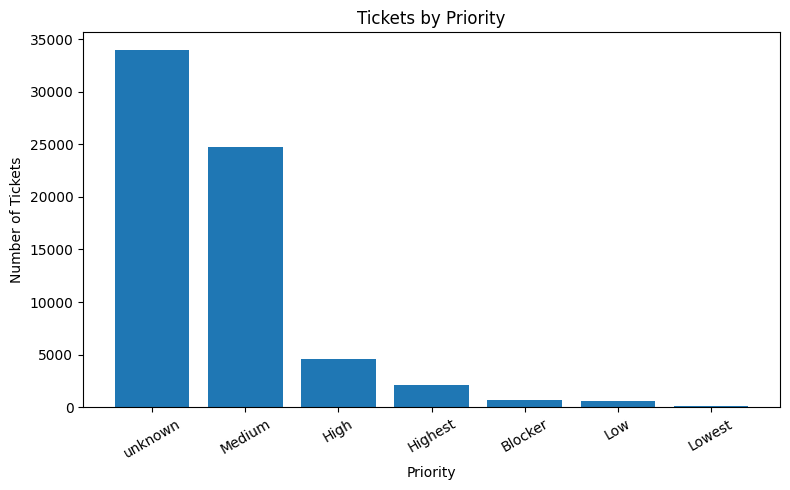

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(priority_counts.index, priority_counts.values)
plt.title("Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 18. Visualization — Tickets by Issue Type

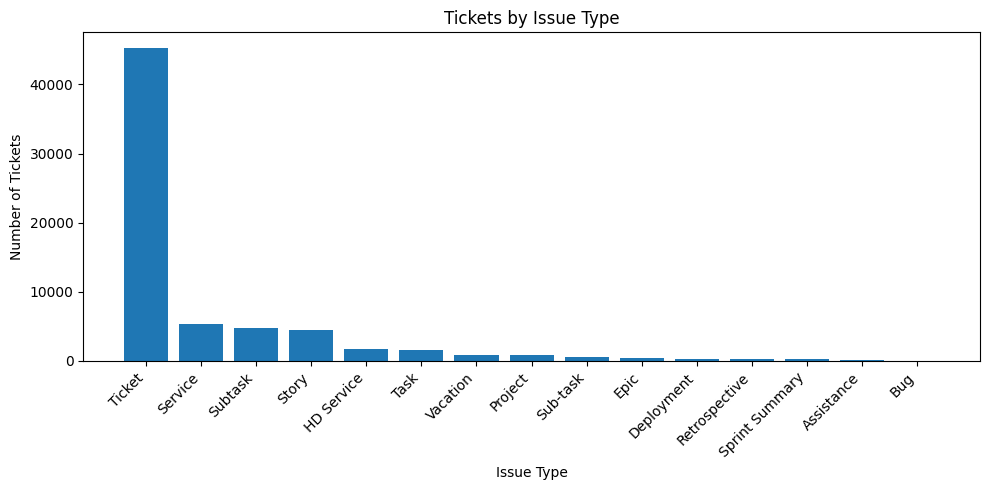

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(type_counts.index, type_counts.values)
plt.title("Tickets by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 19. Visualization — Resolution Time Distribution

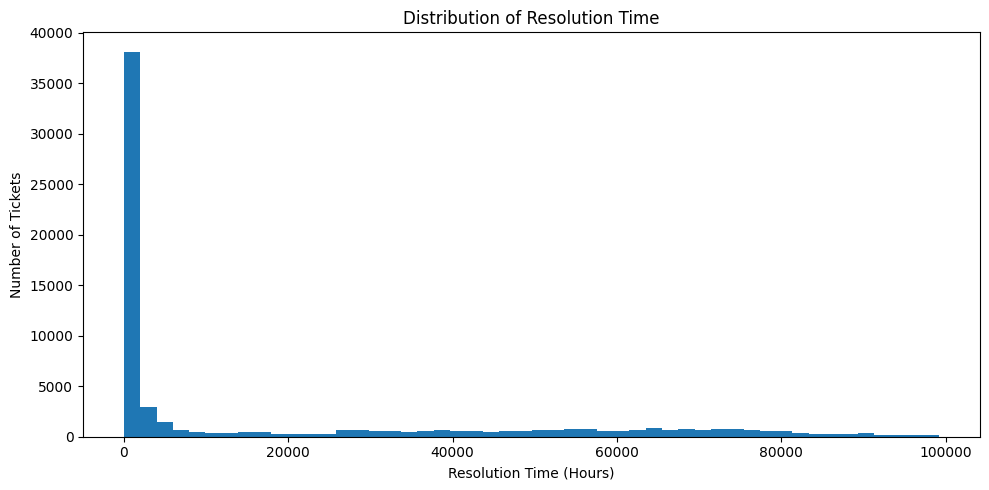

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(resolution_time, bins=50)
plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

## 20. Visualization — Resolution Time by Priority

/tmp/ipykernel_477/4121496159.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=priorities)


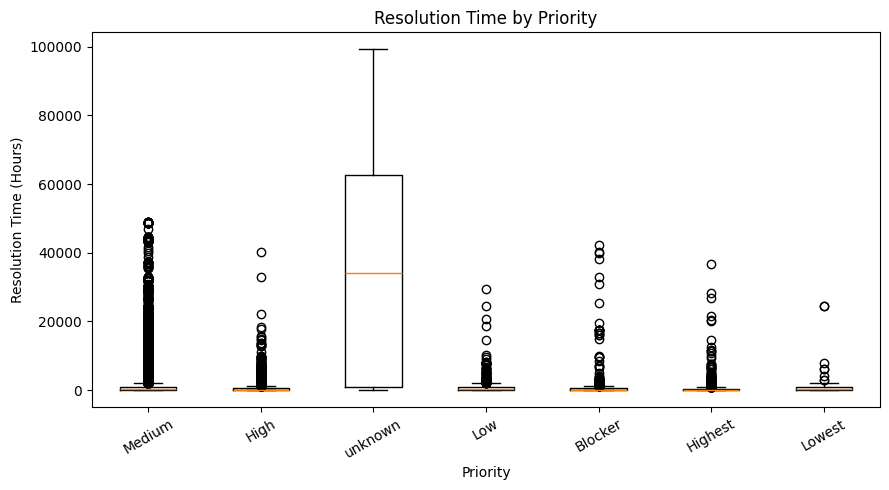

In [22]:
priorities = df_analysis["issue_priority"].dropna().unique()
box_data = [
    df_analysis.loc[
        df_analysis["issue_priority"] == priority,
        "resolution_time_hours"
    ].dropna()
    for priority in priorities
]

plt.figure(figsize=(9, 5))
plt.boxplot(box_data, labels=priorities)
plt.title("Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Resolution Time (Hours)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 21. Visualization — Monthly Ticket Trend

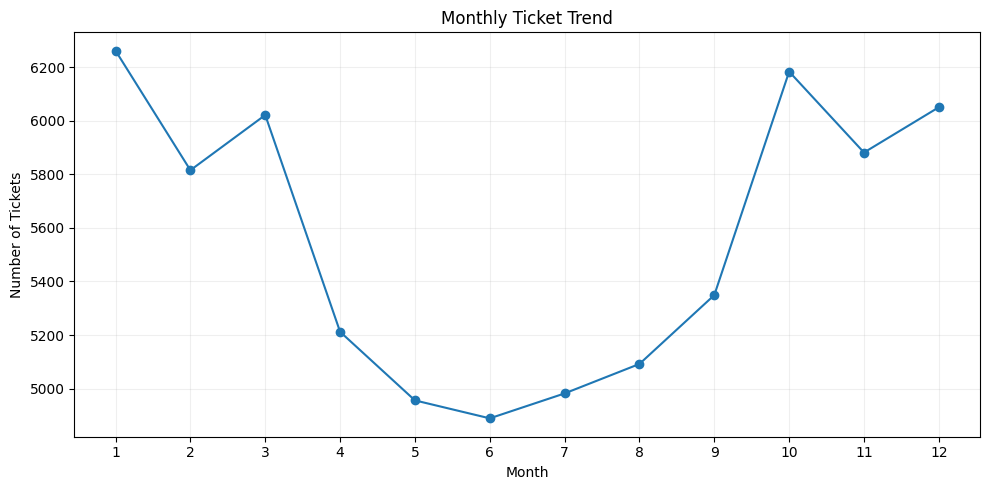

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_tickets.index, monthly_tickets.values, marker="o")
plt.title("Monthly Ticket Trend")
plt.xlabel("Month")
plt.ylabel("Number of Tickets")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 22. Visualization — Comments vs Resolution Time

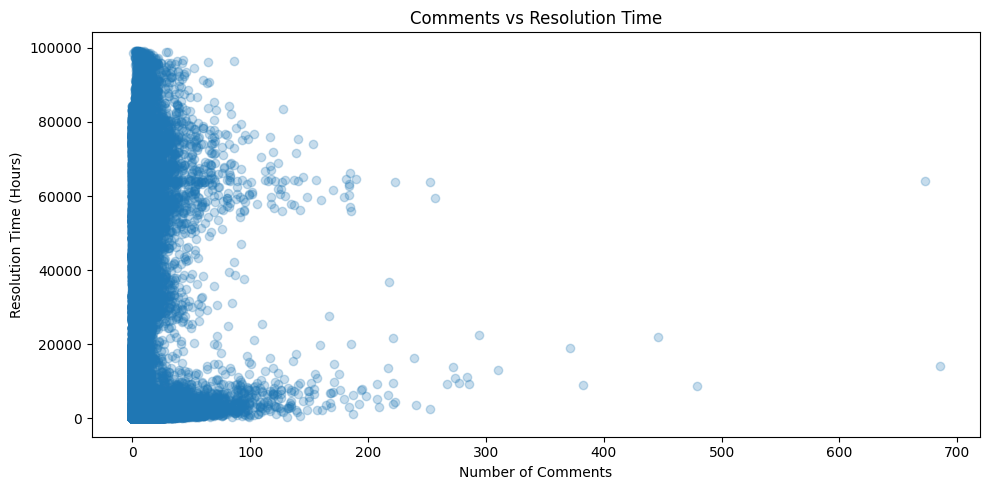

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(
    df_analysis["issue_comments_count"],
    df_analysis["resolution_time_hours"],
    alpha=0.25
)
plt.title("Comments vs Resolution Time")
plt.xlabel("Number of Comments")
plt.ylabel("Resolution Time (Hours)")
plt.tight_layout()
plt.show()

## 23. Key Findings

The exact findings below are based on the calculations produced by the notebook.

- The dataset contains a large number of IT helpdesk tickets.
- Ticket priority and issue type have different ticket volumes.
- Resolution time varies considerably across priorities and issue types.
- Project-wise analysis identifies projects with higher ticket volumes.
- Ticket comments and contributors can be compared with resolution time to identify operational patterns.
- Monthly ticket analysis shows how ticket volume changes across the year.


## 24. Conclusion

The Sprint 1 analysis provides an understanding of the IT helpdesk dataset using Python, NumPy, Pandas, and Matplotlib. The project covers data inspection, cleaning, date processing, resolution-time calculation, statistical analysis, and visualization.

The results provide a foundation for understanding helpdesk operations and resolution patterns. A machine-learning prediction stage can be considered in a later sprint after the required machine-learning topics are covered.
